<a href="https://colab.research.google.com/github/yukthasreeat08/metformin-glipizide-adverse-events/blob/main/metformin_glipizide_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Hello, this is running")

Hello, this is running


In [2]:
drug_name = "metformin"
print("We are studying:", drug_name)

reactions = ["nausea", "dizziness", "headache"]
for reaction in reactions:
  print("Reported reation:", reaction)

We are studying: metformin
Reported reation: nausea
Reported reation: dizziness
Reported reation: headache


In [3]:
import requests

url = "https://api.fda.gov/drug/event.json"
params = {"search": 'patient.drug.medicinalproduct:"metformin"',
    "limit": 5}

response = requests.get(url, params=params)
data = response.json()

print(data.keys())

dict_keys(['meta', 'results'])


In [4]:
first_report = data["results"][0]
print(first_report.keys())

dict_keys(['safetyreportversion', 'safetyreportid', 'primarysourcecountry', 'occurcountry', 'transmissiondateformat', 'transmissiondate', 'reporttype', 'serious', 'receivedateformat', 'receivedate', 'receiptdateformat', 'receiptdate', 'fulfillexpeditecriteria', 'companynumb', 'duplicate', 'reportduplicate', 'primarysource', 'sender', 'receiver', 'patient'])


In [5]:
print(first_report["patient"]["reaction"])

[{'reactionmeddraversionpt': '18.0', 'reactionmeddrapt': 'Medication residue present', 'reactionoutcome': '3'}]


In [6]:
params = {
    "search": 'patient.drug.medicinalproduct:"metformin"',
    "count": "patient.reaction.reactionmeddrapt.exact"
}

response = requests.get(url, params=params)
data = response.json()

print(data["results"][:10])

[{'term': 'NAUSEA', 'count': 29643}, {'term': 'DIARRHOEA', 'count': 27400}, {'term': 'BLOOD GLUCOSE INCREASED', 'count': 26998}, {'term': 'DRUG INEFFECTIVE', 'count': 22106}, {'term': 'FATIGUE', 'count': 20953}, {'term': 'LACTIC ACIDOSIS', 'count': 19534}, {'term': 'VOMITING', 'count': 19170}, {'term': 'ACUTE KIDNEY INJURY', 'count': 17885}, {'term': 'WEIGHT DECREASED', 'count': 17105}, {'term': 'DYSPNOEA', 'count': 16479}]


In [7]:
import pandas as pd

df = pd.DataFrame(data["results"])
df.columns = ["reaction", "count"]
df.head(10)

,reaction,count
0,NAUSEA,29643
1,DIARRHOEA,27400
2,BLOOD GLUCOSE INCREASED,26998
3,DRUG INEFFECTIVE,22106
4,FATIGUE,20953
5,LACTIC ACIDOSIS,19534
6,VOMITING,19170
7,ACUTE KIDNEY INJURY,17885
8,WEIGHT DECREASED,17105
9,DYSPNOEA,16479


In [8]:
df.shape

(100, 2)

In [10]:
df["count"].sum()

np.int64(783392)

In [11]:
def get_top_reactions(drug_name, limit=10):
    params = {
        "search": f'patient.drug.medicinalproduct:"{drug_name}"',
        "count": "patient.reaction.reactionmeddrapt.exact"
    }
    response = requests.get(url, params=params)
    data = response.json()
    df = pd.DataFrame(data["results"][:limit])
    df.columns = ["reaction", "count"]
    df["drug"] = drug_name
    return df

metformin_df = get_top_reactions("metformin")
glipizide_df = get_top_reactions("glipizide")

metformin_df.head()

,reaction,count,drug
0,NAUSEA,29643,metformin
1,DIARRHOEA,27400,metformin
2,BLOOD GLUCOSE INCREASED,26998,metformin
3,DRUG INEFFECTIVE,22106,metformin
4,FATIGUE,20953,metformin


In [12]:
combined_df = pd.concat([metformin_df, glipizide_df])
combined_df

,reaction,count,drug
0,NAUSEA,29643,metformin
1,DIARRHOEA,27400,metformin
2,BLOOD GLUCOSE INCREASED,26998,metformin
3,DRUG INEFFECTIVE,22106,metformin
4,FATIGUE,20953,metformin
5,LACTIC ACIDOSIS,19534,metformin
6,VOMITING,19170,metformin
7,ACUTE KIDNEY INJURY,17885,metformin
8,WEIGHT DECREASED,17105,metformin
9,DYSPNOEA,16479,metformin


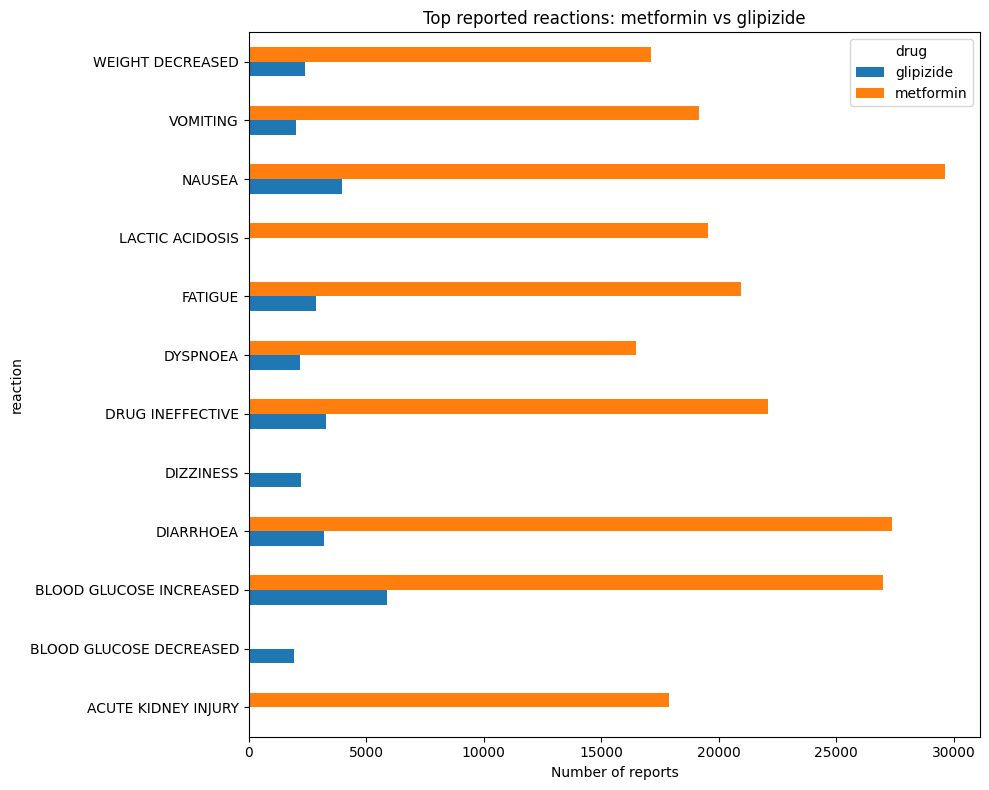

In [14]:
import matplotlib.pyplot as plt

pivot_df = combined_df.pivot(index="reaction", columns="drug", values="count")
pivot_df.plot(kind="barh", figsize=(10, 8))
plt.xlabel("Number of reports")
plt.title("Top reported reactions: metformin vs glipizide")
plt.tight_layout()
plt.show()